In [1]:
import pandas as pd
import seaborn as sns

In [2]:
titanic = pd.read_csv('titanic.csv')
train = pd.read_csv('train.csv')

In [4]:

titanic
train

,ID,W,G,R,AB,H,1B,2B,3B,HR,...,HBP,BBHBP,SF,Outs,Outsinplay,RA,BA,OBA,SLG,OPS
0,1,60,162,558,5336,1280,891,247,31,111,...,0,460,0,4056,3216,740,0.239880,0.300207,0.360195,0.660402
1,3,86,161,677,5620,1492,1147,216,46,83,...,0,531,0,4128,3376,643,0.265480,0.328890,0.364591,0.693480
2,5,79,162,679,5550,1496,1088,262,63,83,...,0,543,0,4054,3175,710,0.269550,0.334646,0.384324,0.718971
3,7,96,162,780,5536,1458,990,265,40,163,...,0,561,0,4078,3145,682,0.263367,0.331146,0.414017,0.745164
4,9,96,162,688,5441,1354,905,247,21,181,...,55,597,35,4087,2703,548,0.248851,0.321258,0.401764,0.723022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,1153,71,162,680,5592,1429,1037,205,29,158,...,0,471,0,4163,3370,826,0.255544,0.313376,0.387339,0.700715
577,1155,76,162,750,5518,1380,871,287,28,194,...,81,680,25,4138,2803,907,0.250091,0.331030,0.417724,0.748754
578,1157,83,162,836,5568,1526,1037,288,39,162,...,75,551,57,4042,3116,867,0.274066,0.336302,0.427083,0.763385
579,1159,67,162,758,5517,1507,1028,278,59,142,...,0,388,0,4010,3066,967,0.273156,0.320914,0.422150,0.743064


In [7]:
tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')
iris = sns.load_dataset('iris')

In [8]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# BELOW IS BIVARIATE ANALYSIS

<Axes: xlabel='total_bill', ylabel='tip'>

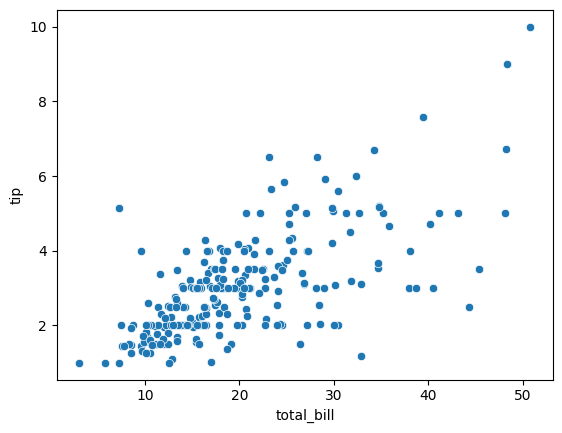

In [10]:
# Scatterplot for two numerical columns.
# Use explicit x/y arguments with seaborn's current API.
sns.scatterplot(data=tips, x='total_bill', y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

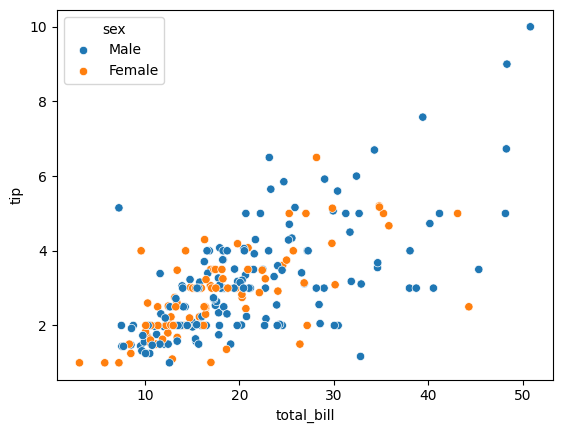

In [ ]:
# Color the points by sex using the column already present in tips.
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex') # we can also introduce category of sex too here

<Axes: xlabel='Pclass', ylabel='Age'>

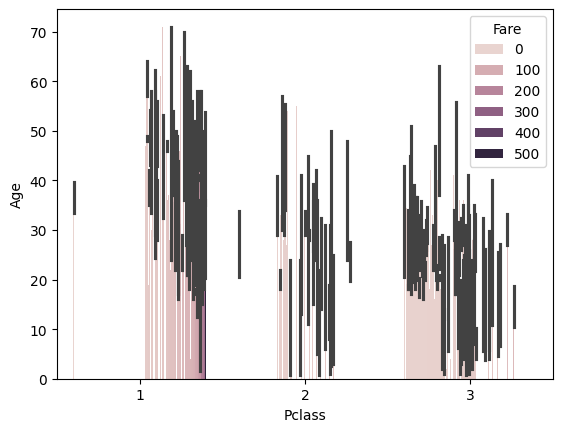

In [16]:
# Bar plot (categorical - numerical)
# Show the average age for each passenger class.
sns.barplot(data=titanic, x='Pclass', y='Age', hue = 'Fare')

<Axes: xlabel='Sex', ylabel='Age'>

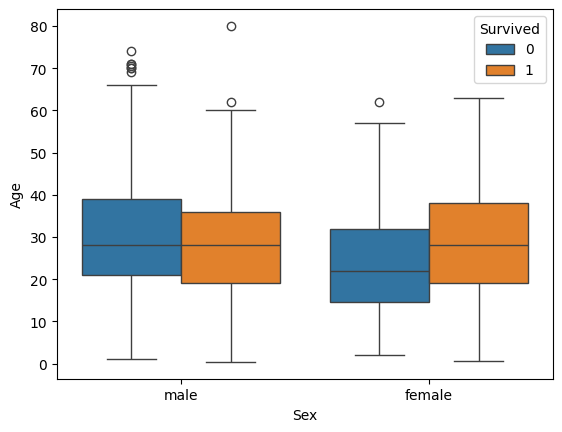

In [19]:
# Boxplot for one numerical column grouped by a categorical column.
# This shows the age distribution for each sex, split by survival status.
sns.boxplot(data=titanic, x='Sex', y='Age', hue='Survived')

/var/folders/pm/wsmly0c92cj7wqpkyfjw91q80000gn/T/ipykernel_9829/1380949880.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived'] == 0]['Age'], hist=False)
/var/folders/pm/wsmly0c92cj7wqpkyfjw91q80000gn/T/ipykernel_9829/1380949880.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

<Axes: xlabel='Age', ylabel='Density'>

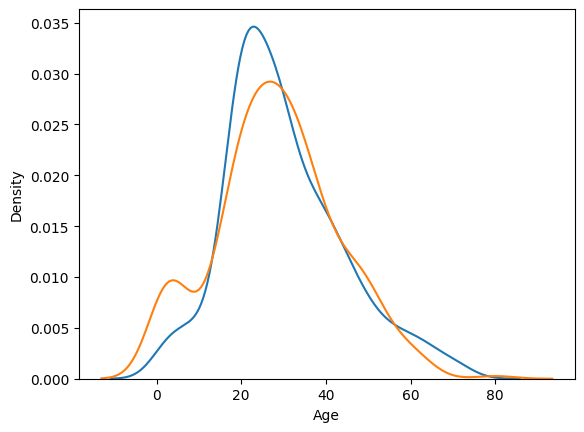

In [20]:
# Distplot for age distribution by survival group.
# hist=False keeps the focus on the distribution curve.
sns.distplot(titanic[titanic['Survived'] == 0]['Age'], hist=False)
sns.distplot(titanic[titanic['Survived'] == 1]['Age'], hist=False)

In [ ]:
pd.crosstab(titanic['Pclass'],titanic['Survived']) # this tells us how many survived in Pclass this is info between two categorical data, and to analyse it we can use heatmap

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,368,119


<Axes: xlabel='Survived', ylabel='Pclass'>

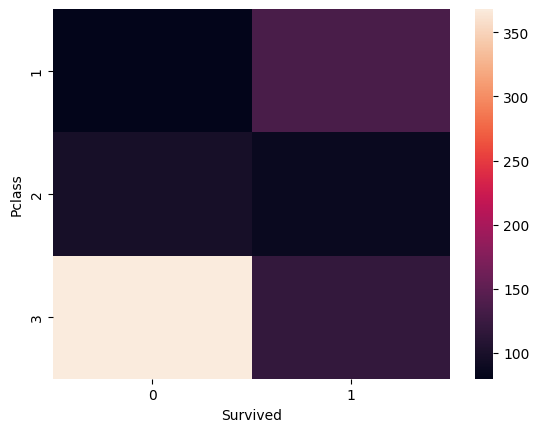

In [ ]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived'])) # heatmap is used to tell people who survived it uses cross tab

In [27]:
# Calculate the survival rate by passenger class.
titanic.groupby('Pclass')['Survived'].mean()*100 # this gives us the answer in percentages

Pclass
1    62.962963
2    47.282609
3    24.435318
Name: Survived, dtype: float64

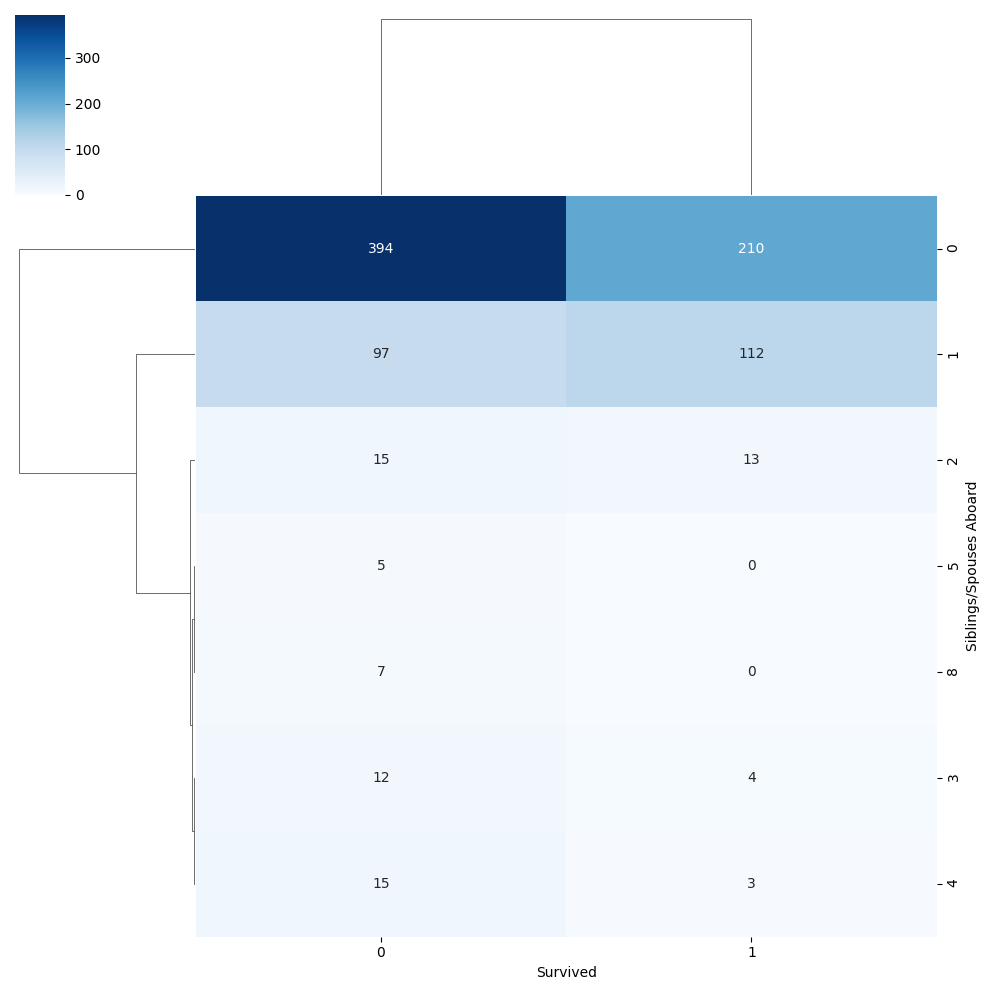

In [ ]:
# Clustermap for the relationship between siblings/spouses aboard and survival.
# First build the contingency table, then visualize it as a clustered heatmap.
sibsp_survived = pd.crosstab(titanic['Siblings/Spouses Aboard'], titanic['Survived'])
sns.clustermap(sibsp_survived, annot=True, fmt='d', cmap='Blues')  # clustermap helps us let us know the closeness

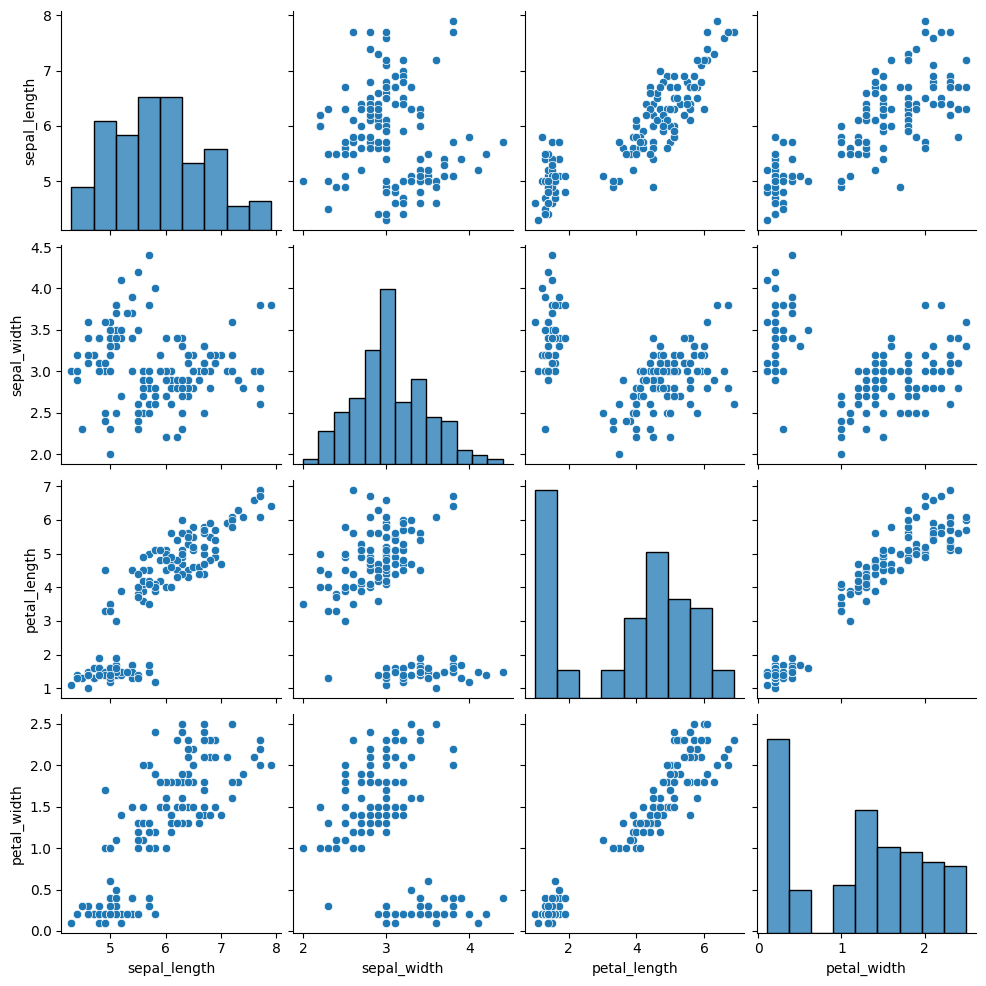

In [7]:
# Pairplot is usually shown on the iris dataset because it has only numerical columns.
# Load the dataset here so the cell works even after a kernel restart.
iris = sns.load_dataset('iris')
sns.pairplot(iris) # this gives us series of scatter plot

In [ ]:
# Lineplot is basically scatterplot joined 

<Axes: xlabel='year', ylabel='passengers'>

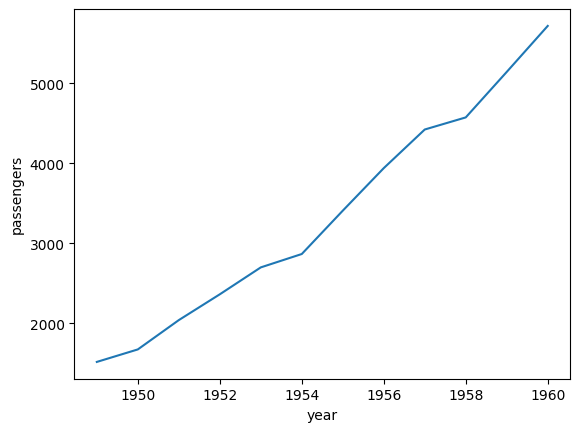

In [9]:
# Lineplot shows how passenger counts change over time.
# Load the flights dataset here so the cell works even after a kernel restart.
flights = sns.load_dataset('flights')
new = flights.groupby('year')['passengers'].sum().reset_index()

# Use explicit x/y arguments with seaborn's current API.
sns.lineplot(data=new, x='year', y='passengers')